## Initial conditions: U=0.2, slope WIDTH varies, tanh bathymetry (test208–test227)

**Changes from original NB1:**
- Resolution: dx = dy = **300 m** (was 100 m)
- Slope widths: **5, 15, 25, 35, 45, 55, 65, 75, 85, 95 km** (was 5–100 km step 5)
- Slope shape: **tanh S-curve** (was linear linspace)
- Ljets: **5, 10, 15 km** only (was 5, 10, 15, 20 km)
- Total: **30 experiments** (was 80)

**Fixed across all experiments:**
- Domain: Lx = 500 km, Ly = 400 km
- U = 0.3 m/s, Yj = 200 km
- Slope height = 400 m (shelf 100 m → basin 500 m)
- Slope centred at Ys = 200 km

| Tests | Ljet | Slope widths |
|-------|------|--------------|
| test208–217 | 5 km | 5,15,25,35,45,55,65,75,85,95 km |
| test218–227 | 10 km | 5,15,25,35,45,55,65,75,85,95 km |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

### Domain and physical constants

In [2]:
# Domain
Lx = 500e3    # m
Ly = 400e3    # m
dx = 300      # m
dy = 300      # m
nx = int(Lx / dx)   # 1666
ny = int(Ly / dy)   # 1333
nxp = nx + 1
nyp = ny + 1

xh = np.linspace(dx/2, nx*dx - dx/2, nx)
yh = np.linspace(dy/2, ny*dy - dy/2, ny)
xq = np.linspace(0, nx*dx, nxp)
yq = np.linspace(0, ny*dy, nyp)

# Physical constants
f = -1e-5   # s^-1
g = 9.81    # m s^-2

# Velocity
U  = 0.30   # m s^-1
Yj = Ly / 2  # m  jet centre (200 km)

# Bathymetry
shallow_depth = 100.0   # m
deep_depth    = 500.0   # m
Ys            = Ly / 2  # m  slope centre (200 km)

print(f'Grid: nx={nx}, ny={ny}  |  {Lx/1e3:.0f} x {Ly/1e3:.0f} km  |  dx={dx} m')

Grid: nx=1666, ny=1333  |  500 x 400 km  |  dx=300 m


### Helper functions

In [3]:
def make_fields(Yj, Ljet, U):
    """Compute velocity and eta fields."""
    Xq_, Yh_u = np.meshgrid(xq, yh)
    Xh_, Yh_h = np.meshgrid(xh, yh)
    yprime_u = (Yh_u - Yj) / Ljet
    yprime_h = (Yh_h - Yj) / Ljet

    u_clean = U * np.tanh(yprime_u)
    v       = np.zeros((nyp, nx))

    rng    = np.random.default_rng(seed=42)
    noise  = rng.standard_normal(u_clean.shape)
    decay  = 1.0 / np.cosh(yprime_u)**2
    u      = u_clean + 1e-3 * decay * noise

    eta_t  = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
    eta_t -= eta_t.mean()
    return u, v, eta_t


def make_bathy_tanh(slope_width_km):
    """Single tanh profile — no piecewise construction.
    Flat shelf (~100m) left of slope centre, smooth S-curve, flat basin (~500m) right.
    steepness set so 90% of depth change occurs within slope_width_km.
    """
    W_m       = slope_width_km * 1e3
    steepness = W_m / (2 * np.arctanh(0.95))

    profile  = shallow_depth + (deep_depth - shallow_depth) * \
               (np.tanh((yh - Ys) / steepness) + 1) / 2

    depth_2d = np.tile(profile[:, np.newaxis], (1, nx))
    return depth_2d


def write_netcdf(input_dir, u, v, eta_t, depth_2d):
    """Write init_vel.nc, init_eta.nc, ocean_topog.nc."""
    zl = 1
    z  = np.array([-250.0])
    u_3d = u    [np.newaxis, :, :]
    v_3d = v    [np.newaxis, :, :]
    h_3d = eta_t[np.newaxis, :, :]

    # init_vel.nc
    nc = Dataset(os.path.join(input_dir, 'init_vel.nc'), 'w', format='NETCDF4')
    nc.createDimension('zl', zl) ; nc.createDimension('yh', ny)
    nc.createDimension('xh', nx) ; nc.createDimension('yq', nyp)
    nc.createDimension('xq', nxp)
    v0=nc.createVariable('zl','f4',('zl',));  v0[:]=z
    v0.axis='Z'; v0.long_name='depth to layer'
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.axis='X'; v0.long_name='h-point longitude'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.axis='Y'; v0.long_name='h-point latitude';  v0.units='meters'
    v0=nc.createVariable('xq','f4',('xq',)); v0[:]=xq
    v0.axis='X'; v0.long_name='q-point longitude'; v0.units='meters'
    v0=nc.createVariable('yq','f4',('yq',)); v0[:]=yq
    v0.axis='Y'; v0.long_name='q-point latitude';  v0.units='meters'
    uv=nc.createVariable('u','f4',('zl','yh','xq')); uv[:]=u_3d
    uv.units='m s-1'; uv.long_name='Eastward velocity'
    uv.standard_name='eastward_sea_water_velocity'
    vv=nc.createVariable('v','f4',('zl','yq','xh')); vv[:]=v_3d
    vv.units='m s-1'; vv.long_name='Northward velocity'
    vv.standard_name='northward_sea_water_velocity'
    nc.regrid_method='bilinear'; nc.close()

    # init_eta.nc
    nc = Dataset(os.path.join(input_dir, 'init_eta.nc'), 'w', format='NETCDF4')
    nc.createDimension('yh', ny); nc.createDimension('xh', nx)
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.axis='X'; v0.long_name='h-point longitude'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.axis='Y'; v0.long_name='h-point latitude';  v0.units='meters'
    hv=nc.createVariable('eta_t','f4',('yh','xh')); hv[:]=h_3d
    hv.units='m'; hv.long_name='Free surface height anomaly'
    hv.standard_name='sea_floor_depth_below_sea_surface'; nc.close()

    # ocean_topog.nc
    nc = Dataset(os.path.join(input_dir, 'ocean_topog.nc'), 'w', format='NETCDF4')
    nc.createDimension('yh', ny); nc.createDimension('xh', nx)
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.long_name='t-cell center x-location'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.long_name='t-cell center y-location'; v0.units='meters'
    dv=nc.createVariable('depth','f4',('yh','xh')); dv[:]=depth_2d
    dv.units='m'; dv.long_name='ocean bottom depth'
    dv.standard_name='sea_floor_depth_below_geoid'; nc.close()

### Experiment definitions

In [4]:
base_dir = '/scratch/nm03/ae7501/mom6_input_directories/idealized'

# Slope widths: 5 to 95 km in steps of 10 km
slope_widths_km = list(range(5, 96, 10))   # [5,15,25,35,45,55,65,75,85,95]

experiments = []
n = 208
for Ljet_km in [5, 10]:
    for w_km in slope_widths_km:
        experiments.append(dict(
            exp_num    = n,
            Ljet       = Ljet_km * 1e3,
            Ljet_km    = Ljet_km,
            U          = 0.3,
            slope_w_km = w_km))
        n += 1

print(f'{len(experiments)} experiments: test{experiments[0]["exp_num"]} – test{experiments[-1]["exp_num"]}')
print(f'Slope widths (km): {slope_widths_km}')

20 experiments: test208 – test227
Slope widths (km): [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]


### Main loop

In [5]:
cached_key, cached_fields = None, None

for exp in experiments:
    exp_name  = f'test{exp["exp_num"]}'
    input_dir = os.path.join(base_dir, exp_name, 'INPUT')
    os.makedirs(input_dir, exist_ok=True)

    # Recompute velocity only when Ljet changes
    vel_key = (exp['Ljet'], exp['U'])
    if vel_key != cached_key:
        cached_fields = make_fields(Yj, exp['Ljet'], exp['U'])
        cached_key    = vel_key
    u, v, eta_t = cached_fields

    # Bathymetry with tanh slope
    
    depth_2d = make_bathy_tanh(exp['slope_w_km'])
    write_netcdf(input_dir, u, v, eta_t, depth_2d)
    print(f"{exp_name}: Ljet={exp['Ljet_km']}km  W={exp['slope_w_km']}km")

print(f"\n{'='*60}\nDone. {len(experiments)} experiments written.\n{'='*60}")

test208: Ljet=5km  W=5km
test209: Ljet=5km  W=15km
test210: Ljet=5km  W=25km
test211: Ljet=5km  W=35km
test212: Ljet=5km  W=45km
test213: Ljet=5km  W=55km
test214: Ljet=5km  W=65km
test215: Ljet=5km  W=75km
test216: Ljet=5km  W=85km
test217: Ljet=5km  W=95km
test218: Ljet=10km  W=5km
test219: Ljet=10km  W=15km
test220: Ljet=10km  W=25km
test221: Ljet=10km  W=35km
test222: Ljet=10km  W=45km
test223: Ljet=10km  W=55km
test224: Ljet=10km  W=65km
test225: Ljet=10km  W=75km
test226: Ljet=10km  W=85km
test227: Ljet=10km  W=95km

Done. 20 experiments written.


### S tanh bathymetry profiles

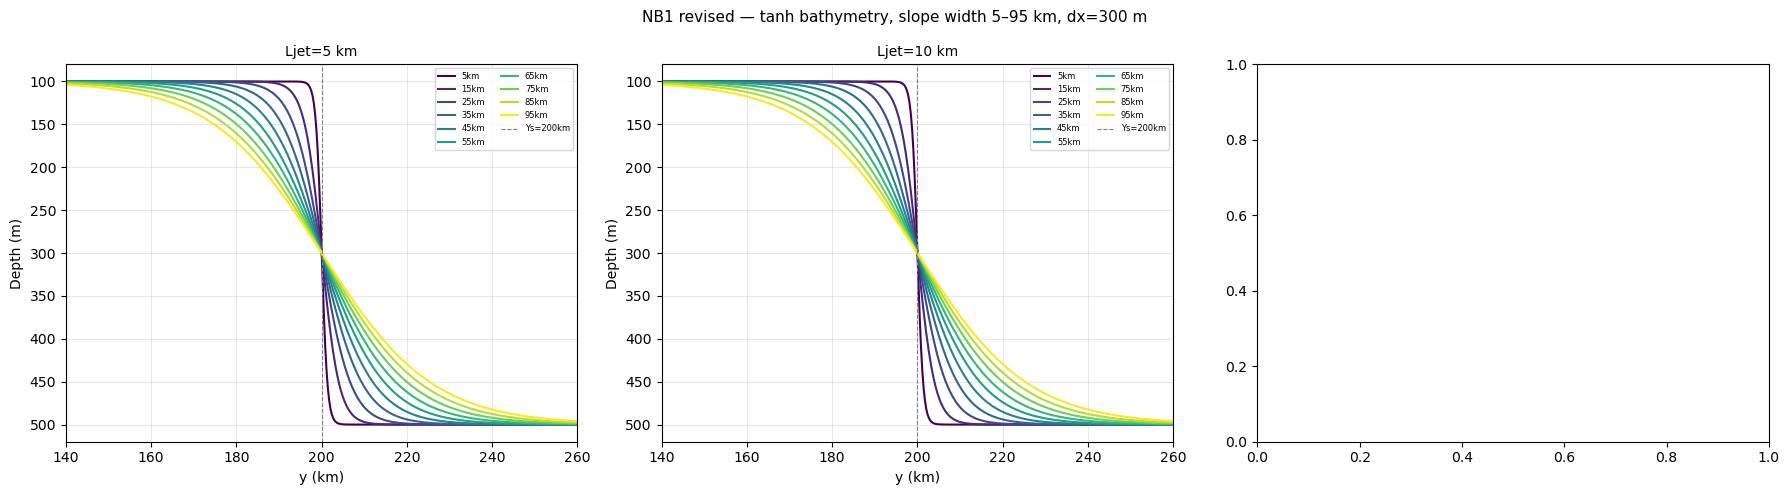

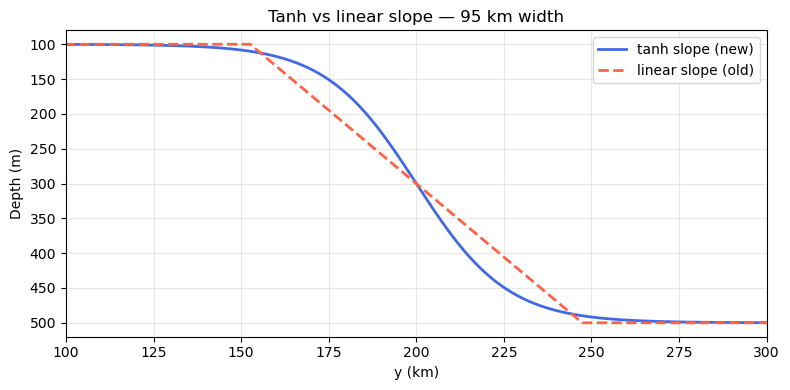

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, Ljet_km in zip(axes, [5, 10]):
    sub    = [e for e in experiments if e['Ljet_km'] == Ljet_km]
    colors = plt.cm.viridis(np.linspace(0, 1, len(sub)))

    for i, exp in enumerate(sub):
        depth_2d = make_bathy_tanh(exp['slope_w_km'])
        ax.plot(yh/1e3, depth_2d[:,0], color=colors[i],
                label=f"{exp['slope_w_km']}km")

    ax.axvline(Ys/1e3, color='gray', ls='--', lw=0.8, label=f'Ys={Ys/1e3:.0f}km')
    ax.set_xlim(Ys/1e3 - 60, Ys/1e3 + 60)
    ax.invert_yaxis()
    ax.set_xlabel('y (km)', fontsize=10)
    ax.set_ylabel('Depth (m)', fontsize=10)
    ax.set_title(f'Ljet={Ljet_km} km', fontsize=10)
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('NB1 revised — tanh bathymetry, slope width 5–95 km, dx=300 m', fontsize=11)
plt.tight_layout()
plt.show()

# Compare tanh vs linear for one case
fig, ax = plt.subplots(figsize=(8, 4))
w_km = 95
d_tanh = make_bathy_tanh(w_km)

# Linear equivalent for comparison
W_m   = w_km * 1e3
sw    = int(round(W_m / dy))
ss    = int(round((Ys - W_m/2) / dy))
se    = ss + sw
d_lin = np.zeros(ny)
d_lin[:ss]   = shallow_depth
d_lin[ss:se] = np.linspace(shallow_depth, deep_depth, sw)
d_lin[se:]   = deep_depth

ax.plot(yh/1e3, d_tanh[:,0], 'royalblue', lw=2, label='tanh slope (new)')
ax.plot(yh/1e3, d_lin,        'tomato',    lw=2, ls='--', label='linear slope (old)')
ax.set_xlim(Ys/1e3 - w_km - 5, Ys/1e3 + w_km + 5)
ax.invert_yaxis()
ax.set_xlabel('y (km)'); ax.set_ylabel('Depth (m)')
ax.set_title(f'Tanh vs linear slope — {w_km} km width')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()